# Recreation of Mapping Algorithm from Phase -> Spatial

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [33]:
class BitEncoder:
    def __init__(self):
        self.shifted_values = torch.arange(24)
        self.shifted_values = 1 << self.shifted_values

class Encode_Visible:
    def __init__(self):
        self.be = BitEncoder()
        self.m_plm_visible_logical_masks = torch.tensor([
            [[1, 0], [1, 0]],  
            [[1, 0], [0, 0]],  
            [[0, 0], [1, 0]],  
            [[1, 0], [1, 1]],  
            [[0, 0], [0, 0]],  
            [[1, 0], [0, 1]],  
            [[0, 0], [1, 1]],  
            [[0, 0], [0, 1]],  
            [[1, 1], [1, 0]],  
            [[1, 1], [0, 0]],  
            [[0, 1], [1, 0]],  
            [[0, 1], [0, 0]],  
            [[1, 1], [1, 1]],  
            [[1, 1], [0, 1]],  
            [[0, 1], [1, 1]],  
            [[0, 1], [0, 1]]   
        ], dtype=torch.float32)

    def encode(self, x : torch.Tensor):
        N = x.shape[0]
        input_h = x.shape[1]
        input_w = x.shape[2]

        logical = self.m_plm_visible_logical_masks[x]
        logical = logical.view(N, input_h, input_w, 2, 2)
        logical = logical.permute(0, 1, 3, 2, 4).contiguous()
        logical = logical.view(N, input_h * 2, input_w * 2)

        shifts_used = self.be.shifted_values[:N].to(logical.device).view(N, 1, 1)
        logical     = logical.to(torch.int32)
        logical     = torch.sum(logical * shifts_used, dim=0)
        logical     = torch.fliplr(logical)
        return logical
    
class Encode_NIR:
    def __init__(self):
        self.be = BitEncoder()
        self.m_plm_nir_logical_masks = torch.tensor([
            [
                [0, 0, 0], [0, 0, 0] 
            ],
            [
                [0, 0, 0], [0, 1, 0] 
            ],
            [
                [0, 1, 0], [0, 0, 0] 
            ],
            [
                [0, 1, 0], [0, 1, 0] 
            ],
            [
                [0, 0, 1], [1, 0, 0] 
            ],
            [
                [0, 0, 1], [1, 1, 0] 
            ],
            [
                [0, 1, 1], [1, 0, 0] 
            ],
            [
                [0, 1, 1], [1, 1, 0] 
            ],
            [
                [1, 0, 0], [0, 0, 0] 
            ],
            [
                [1, 0, 0], [0, 1, 0] 
            ],
            [
                [1, 1, 0], [0, 0, 0] 
            ],
            [
                [1, 1, 0], [0, 1, 0] 
            ],
            [
                [1, 0, 1], [1, 0, 0] 
            ],
            [
                [1, 0, 1], [1, 1, 0] 
            ],
            [
                [1, 1, 1], [1, 0, 0] 
            ],
            [
                [1, 1, 1], [1, 1, 0] 
            ],
            [
                [0, 0, 0], [0, 0, 1] 
            ],
            [
                [0, 0, 0], [0, 1, 1] 
            ],
            [
                [0, 1, 0], [0, 0, 1] 
            ],
            [
                [0, 1, 0], [0, 1, 1] 
            ],
            [
                [0, 0, 1], [1, 0, 1] 
            ],
            [
                [0, 0, 1], [1, 1, 1] 
            ],
            [
                [0, 1, 1], [1, 0, 1] 
            ],
            [
                [0, 1, 1], [1, 1, 1] 
            ],
            [
                [1, 0, 0], [0, 0, 1] 
            ],
            [
                [1, 0, 0], [1, 1, 0] 
            ],
            [
                [1, 1, 0], [0, 0, 1] 
            ],
            [
                [1, 1, 0], [0, 1, 1] 
            ],
            [
                [1, 0, 1], [1, 0 ,1] 
            ],
            [
                [1 ,0 ,1], [1 ,1 ,1] 
            ],
            [
                [1 ,1 ,1], [1 ,0 ,1] 
            ],
            [
                [1, 1, 1], [1, 1, 1] 
            ]
        ])

    def encode(self, x : torch.Tensor):
        N = x.shape[0]
        input_h = x.shape[1]
        input_w = x.shape[2]

        logical = self.m_plm_nir_logical_masks[x]
        logical = logical.view(N, input_h, input_w, 2, 3)
        logical = logical.permute(0, 1, 3, 2, 4).contiguous()
        logical = logical.view(N, input_h * 2, input_w * 3)

        shifts_used = self.be.shifted_values[:N].to(logical.device).view(N, 1, 1)
        logical     = logical.to(torch.int32)
        logical     = torch.sum(logical * shifts_used, dim=0)
        logical     = torch.fliplr(logical)

        # Zero padd left and
        # right side by 2 columns
        logical = torch.nn.functional.pad(logical, (2, 2), mode='constant', value=0)

        return logical


Input Tensor:
tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11],
         [12, 13, 14, 15]]])


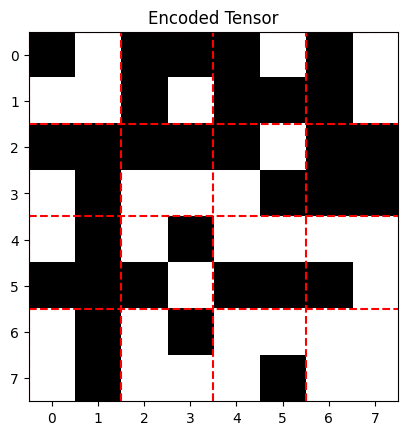

In [34]:
# Create a input tensor
# of shape (1, 4, 4)
# where values range from 0 to 15
x = torch.arange(16).reshape(1, 4, 4)
print("Input Tensor:")
print(x)

y = Encode_Visible().encode(x)

# visualize
plt.imshow(y.cpu().numpy(), cmap='gray')
plt.title("Encoded Tensor")

# draw lines to show the 2x2 blocks
for i in range(0, y.shape[0], 2):
    plt.axhline(i - 0.5, color='red', linestyle='--')
for j in range(0, y.shape[1], 2):
    plt.axvline(j - 0.5, color='red', linestyle='--')

plt.show()

Input Tensor:
tensor([[[ 0,  1,  2,  3,  4,  5,  6,  7],
         [ 8,  9, 10, 11, 12, 13, 14, 15],
         [16, 17, 18, 19, 20, 21, 22, 23],
         [24, 25, 26, 27, 28, 29, 30, 31]]])


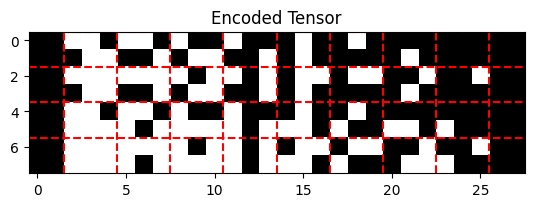

In [42]:
# Create a input tensor
# of values in range of 0 to 31

# reshape x into a 2d tensor of shape (1, 4, 8)
# where values range from 0 to 31
x = torch.arange(32).reshape(1, 4, 8)

print("Input Tensor:")
print(x)

y = Encode_NIR().encode(x)

# visualize
plt.imshow(y.cpu().numpy(), cmap='gray')
plt.title("Encoded Tensor")

# Account for the 2 columns of zero padding on left and right side
# by starting 2 columns in when drawing vertical lines
# draw lines to show the 2x3 blocks
for i in range(0, y.shape[0], 2):
    plt.axhline(i - 0.5, color='red', linestyle='--')
for j in range(2, y.shape[1], 3):
    plt.axvline(j - 0.5, color='red', linestyle='--')

plt.show()